### L1L2Mix model training

Let's train a model using our baseline setup *with L1L2Mix regulization*. My network contains 3 hidden layers and 128 hidden units with ReLU activation function. I use the Adam optimiser with a learning rate of 10−4.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import logging
# import sys
# sys.path.append('/path/to/mlpractical')

from mlp.data_providers import MNISTDataProvider, EMNISTDataProvider
from mlp.layers import AffineLayer, SoftmaxLayer, SigmoidLayer, ReluLayer, CustomActivationLayer, DropoutLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser
from mlp.train_model_and_plot_stats import train_model_and_plot_stats
from mlp.penalties import L1L2MixPenalty

In [2]:
# The below code will set up the data providers, random number
# generator and logger objects needed for training runs. As
# loading the data from file take a little while you generally
# will probably not want to reload the data providers on
# every training run. If you wish to reset their state you
# should instead use the .reset() method of the data providers.

# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng, smooth_labels=False)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng, smooth_labels=False)

KeysView(NpzFile '/Users/hallaei/UoE/mlp/mlpractical/data/emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile '/Users/hallaei/UoE/mlp/mlpractical/data/emnist-valid.npz' with keys: inputs, targets)


In [3]:
# Setup hyperparameters
learning_rate = 0.0001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

Run 1 - lambda: 0.0005, alpha: 0.25


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 3.7s to complete
    error(train)=5.38e-01, acc(train)=8.32e-01, error(valid)=5.63e-01, acc(valid)=8.21e-01


Entered log stats


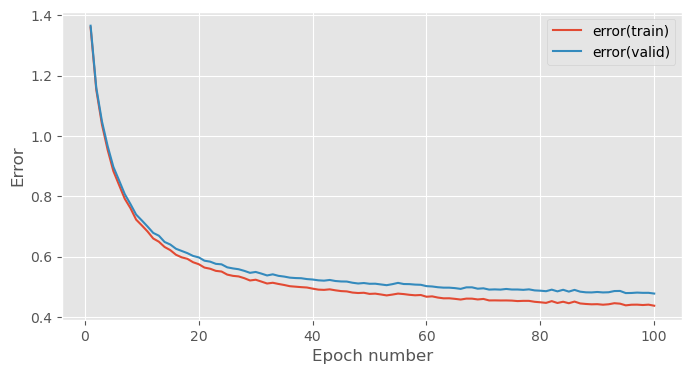

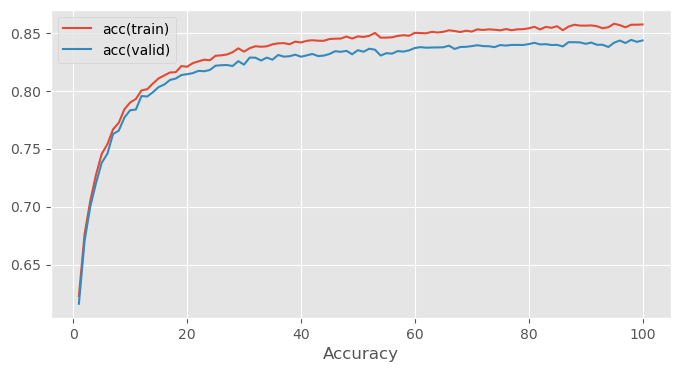

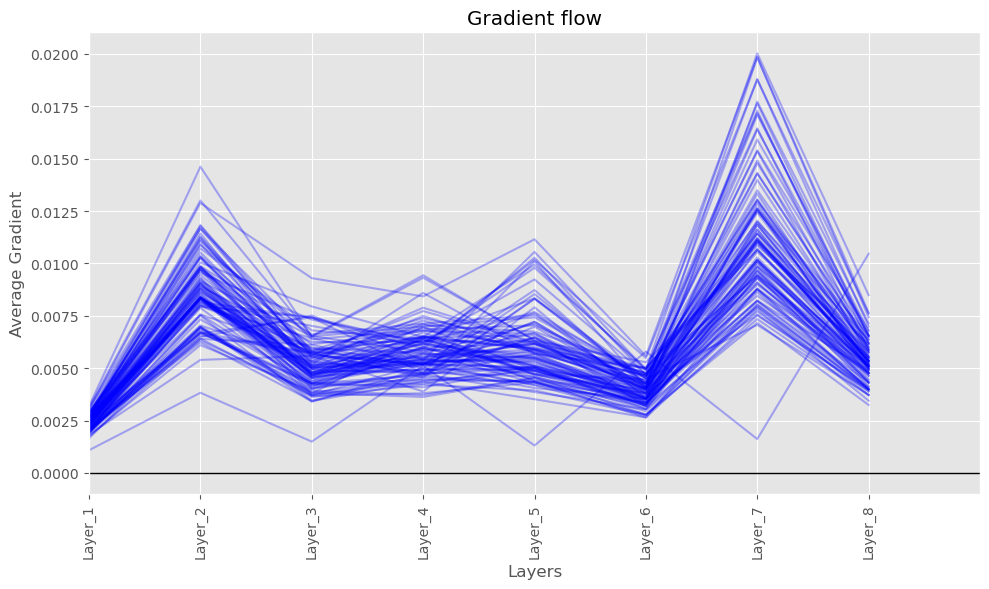

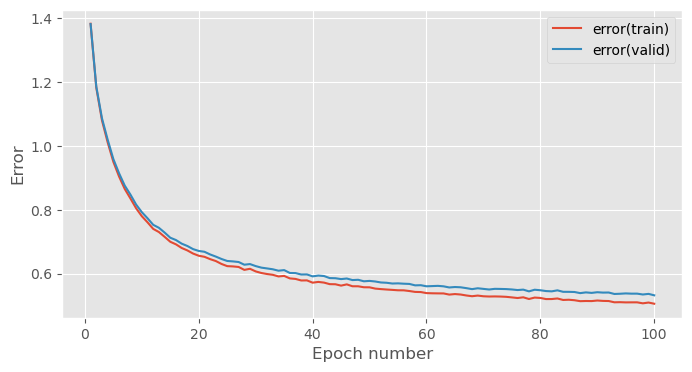

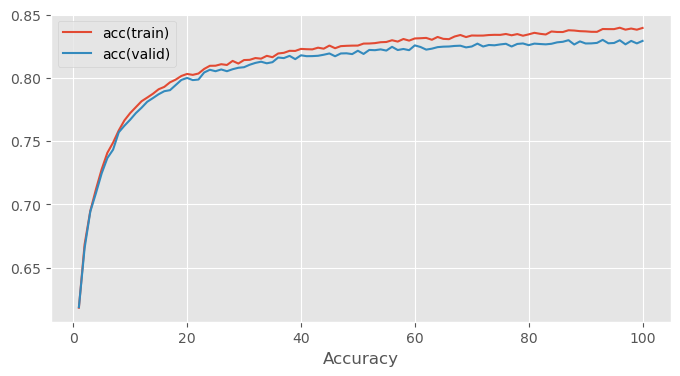

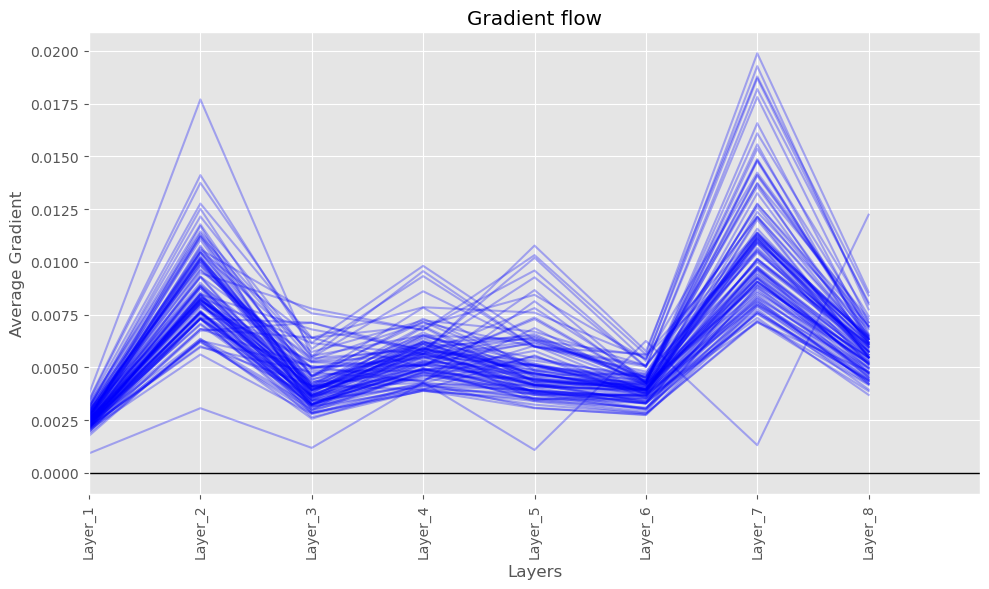

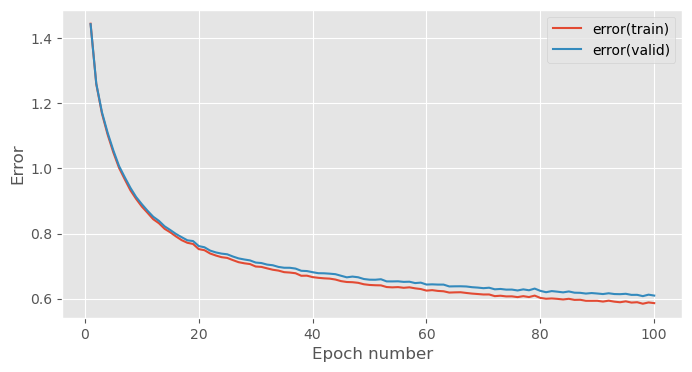

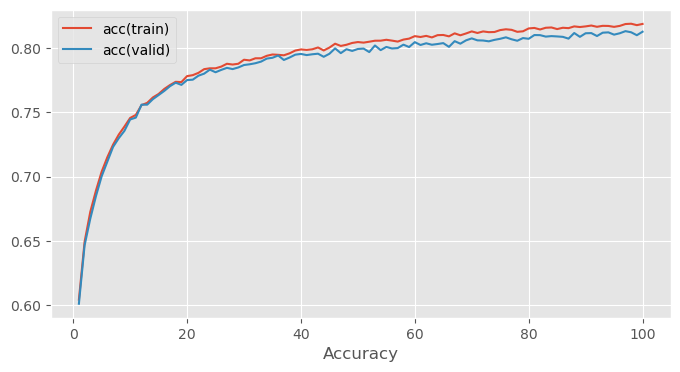

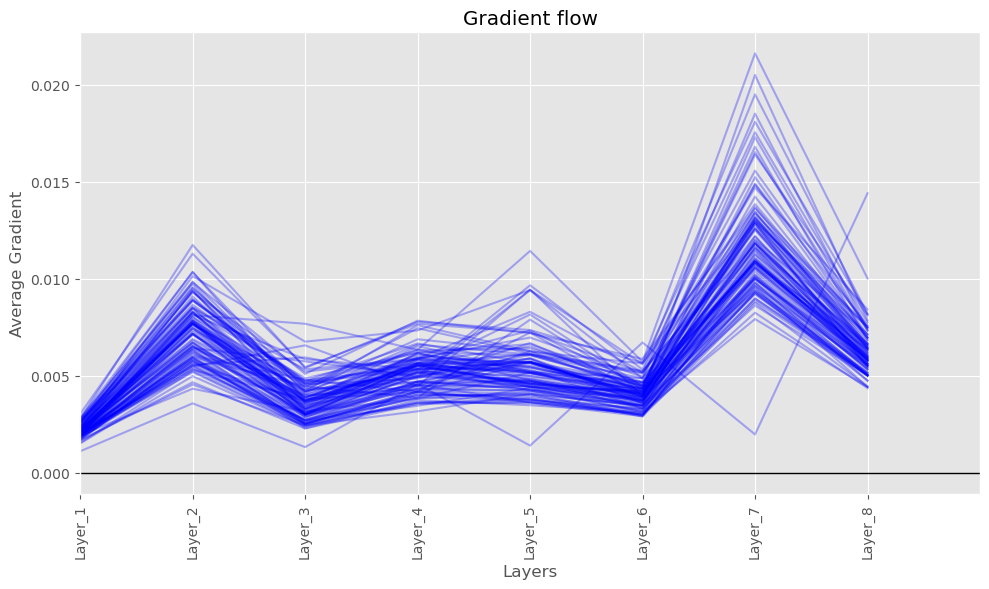

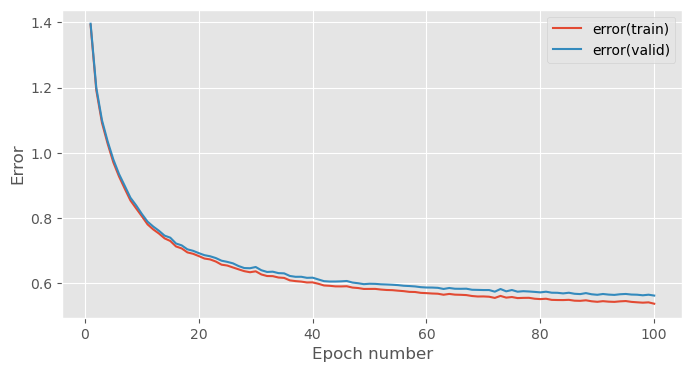

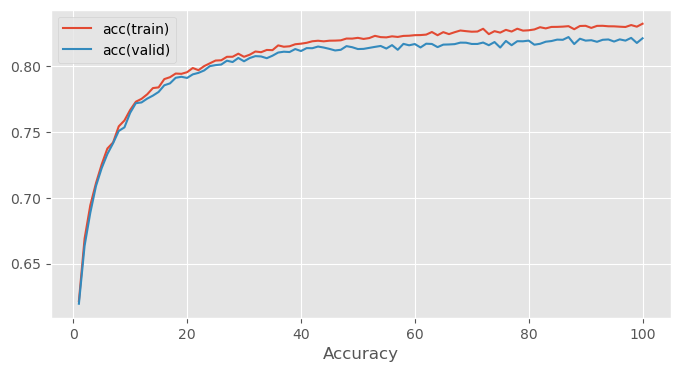

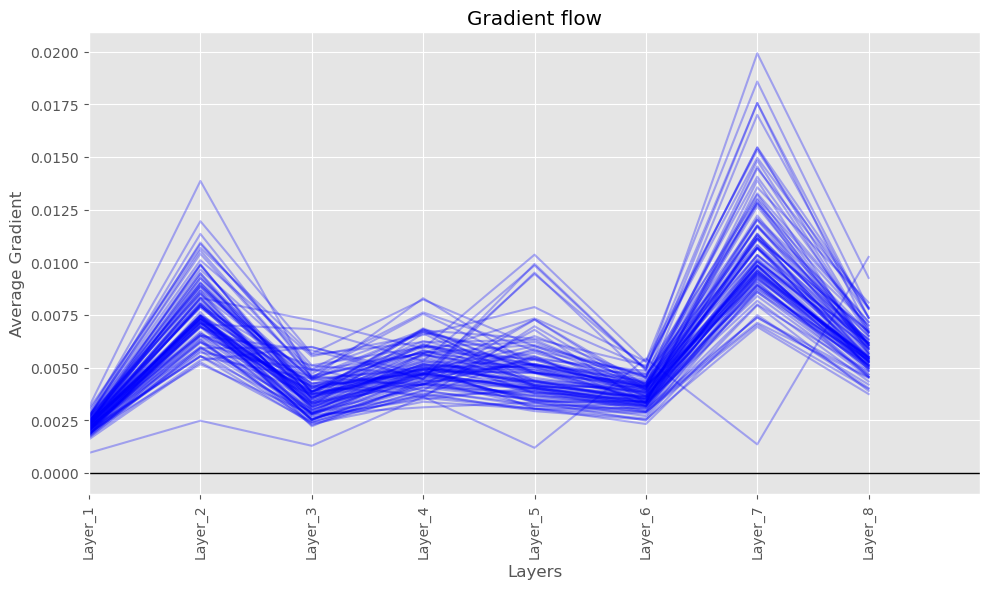

In [4]:
# Create model with three hidden layers and L1 penalties on weights and biases

# lambda = decay coefficient
lamda = [5e-4, 5e-4, 5e-4, 1e-3]

# alpha = mixing term between L1 and L2
alpha = [0.25, 0.50, 0.75, 0.25]

stats_all_runs = {}

for i in range(len(lamda)):
  print(f"Run {i+1} - lambda: {lamda[i]}, alpha: {alpha[i]}")
  weights_init = GlorotUniformInit(rng=rng)
  biases_init = ConstantInit(0.)
  error =  CrossEntropySoftmaxError()
  # Use a Adam learning rule
  learning_rule = AdamLearningRule(learning_rate=learning_rate)
  model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init,
              weights_penalty=L1L2MixPenalty(lamda[i], alpha[i]),
              biases_penalty=L1L2MixPenalty(lamda[i], alpha[i])),
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init,
              weights_penalty=L1L2MixPenalty(lamda[i], alpha[i]),
              biases_penalty=L1L2MixPenalty(lamda[i], alpha[i])),
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init,
              weights_penalty=L1L2MixPenalty(lamda[i], alpha[i]),
              biases_penalty=L1L2MixPenalty(lamda[i], alpha[i])),
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init,
              weights_penalty=L1L2MixPenalty(lamda[i], alpha[i]),
              biases_penalty=L1L2MixPenalty(lamda[i], alpha[i])) # output layer
  ])

  stats, keys, run_time, fig_1, ax_1, fig_2ç, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
      model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)
  stats_all_runs[i] = stats



In [ ]:
# get all stats from run
import pickle
with open('/Users/hallaei/UoE/mlp/mlpractical/data/emnist_l1l2_mixing_stats.pkl', 'rb') as f:
    stats_all_runs = pickle.load(f)

[[3.86408814 0.02543    3.86719278 0.02436709]
 [1.36012154 0.6228     1.36545016 0.61613924]
 [1.15296633 0.67635    1.15996663 0.67056962]
 [1.0377255  0.70501    1.04795992 0.70006329]
 [0.95374759 0.72744    0.96630517 0.72018987]
 [0.88365489 0.74544    0.897668   0.7378481 ]
 [0.83765897 0.75385    0.85295987 0.74563291]
 [0.79188798 0.76677    0.80731825 0.76272152]
 [0.76072539 0.77238    0.77436661 0.76556962]
 [0.72266273 0.78409    0.7393127  0.77696203]
 [0.70348813 0.78993    0.71992227 0.78322785]
 [0.68341571 0.79291    0.69982735 0.78379747]
 [0.66014771 0.80036    0.67861862 0.79550633]
 [0.64934757 0.8014     0.66924167 0.79506329]
 [0.63191442 0.80628    0.64852899 0.79879747]
 [0.62148237 0.81073    0.64010953 0.80322785]
 [0.60613743 0.81328    0.62601478 0.80544304]
 [0.59763421 0.81582    0.61876313 0.80936709]
 [0.59266078 0.81607    0.61155806 0.81056962]
 [0.58141094 0.82134    0.60230016 0.81360759]
 [0.57484949 0.82076    0.59747271 0.81436709]
 [0.56368636 